## Hierarchical Clustering — Sample Superstore
**Objective:** Segment customers based on their purchasing behaviour (Sales, Profit, Quantity, Discount)  
using Agglomerative Hierarchical Clustering.

---
**Workflow**
1. Install & import libraries  
2. Load & explore the dataset  
3. Feature engineering — aggregate to customer level  
4. Pre-processing — scale features  
5. Assess cluster tendency (Hopkins Statistic)  
6. Build linkage matrix & plot dendrogram  
7. Choose optimal *k* via Silhouette Score  
8. Fit final model & visualise clusters  
9. Profile & interpret each cluster  
10. Visualise Clusters
11. Cluster Profiling & Business Interpretation



## 1 . Install Dependencies

In [4]:
!pip install scikit-learn scipy matplotlib seaborn openpyxl --quiet

## 2 . Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

plt.rcParams.update({
    "figure.facecolor": "#0F1117",
    "axes.facecolor":   "#0F1117",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#AAAAAA",
    "xtick.color":      "#777777",
    "ytick.color":      "#777777",
    "text.color":       "white",
    "grid.color":       "#222222",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
})

PALETTE = ["#E63946", "#2A9D8F", "#F4A261", "#457B9D",
           "#A8DADC", "#264653", "#E9C46A", "#8338EC"]
print("✅ Libraries loaded.")

✅ Libraries loaded.


## 3 . Load & Explore the Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#  Load & Inspect

file_path = '/content/drive/My Drive/Datasets/Sample_Superstore.csv'

try:
    df = pd.read_csv(file_path, encoding='cp1252')
    print("Dataset loaded successfully!")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")

except UnicodeDecodeError:
    print("Encoding issue detected. Trying fallback encoding...")
    try:
        df = pd.read_csv(file_path, encoding='latin1')
        print("Loaded with fallback encoding (latin1).")
    except Exception as e:
        print(f"Still failed: {e}")

except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Dataset loaded successfully!


In [8]:
print(f"Shape: {df.shape}")
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
print("Missing values:\n", df.isnull().sum())
print("\nNumerical summary:")
df[["Sales", "Profit", "Quantity", "Discount"]].describe().round(2)

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Numerical summary:


,Sales,Profit,Quantity,Discount
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,3.79,0.16
std,623.25,234.26,2.23,0.21
min,0.44,-6599.98,1.00,0.00
25%,17.28,1.73,2.00,0.00
50%,54.49,8.67,3.00,0.20
75%,209.94,29.36,5.00,0.20
max,22638.48,8399.98,14.00,0.80


## 4 · Feature Engineering - Customer-Level Aggregation

> Add blockquote



Each row is an **order line item**. For clustering we need one row per customer.  
We aggregate to four behavioural signals:

| Feature | Meaning |
|---|---|
| `Total_Sales` | Total revenue the customer generated |
| `Total_Profit` | Total profit contribution |
| `Total_Quantity` | Total units ordered |
| `Avg_Discount` | Average discount received |


In [11]:
customer_df = df.groupby("Customer ID").agg(
    Customer_Name = ("Customer Name", "first"),
    Segment       = ("Segment",       "first"),
    Total_Sales   = ("Sales",         "sum"),
    Total_Profit  = ("Profit",        "sum"),
    Total_Quantity= ("Quantity",      "sum"),
    Avg_Discount  = ("Discount",      "mean"),
).reset_index()

print(f"Unique customers: {len(customer_df)}")
customer_df.head()

Unique customers: 793


,Customer ID,Customer_Name,Segment,Total_Sales,Total_Profit,Total_Quantity,Avg_Discount
0,AA-10315,Alex Avila,Consumer,5563.560,-362.8825,30,0.090909
1,AA-10375,Allen Armold,Consumer,1056.390,277.3824,41,0.080000
2,AA-10480,Andrew Allen,Consumer,1790.512,435.8274,36,0.016667
3,AA-10645,Anna Andreadi,Consumer,5086.935,857.8033,64,0.063889
4,AB-10015,Aaron Bergman,Consumer,886.156,129.3465,13,0.066667


## 5 . Preprocessing - Scalling

In [12]:
features = ["Total_Sales", "Total_Profit", "Total_Quantity", "Avg_Discount"]
X = customer_df[features].values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Mean after scaling (should be ~0):", X_scaled.mean(axis=0).round(4))
print("Std  after scaling (should be ~1):", X_scaled.std(axis=0).round(4))

Feature matrix shape: (793, 4)
Mean after scaling (should be ~0): [ 0. -0. -0.  0.]
Std  after scaling (should be ~1): [1. 1. 1. 1.]


## 6 · Cluster Tendency — Hopkins Statistic

Before clustering, check whether the data **actually has cluster structure**.  
- Hopkins score **> 0.5** → clustering is meaningful  
- Score **≈ 0.5** → data is random (clustering would be arbitrary)


In [13]:
def hopkins_statistic(X, sample_ratio=0.1, random_state=42):
    np.random.seed(random_state)
    n, d = X.shape
    m = max(int(n * sample_ratio), 5)

    # Random sample from data
    idx = np.random.choice(n, m, replace=False)
    X_sample = X[idx]

    # Fit NN on full data (excluding sample)
    mask = np.ones(n, dtype=bool)
    mask[idx] = False
    nbrs = NearestNeighbors(n_neighbors=1).fit(X[mask])
    u_dist, _ = nbrs.kneighbors(X_sample)

    # Random points from bounding box
    mins, maxs = X.min(axis=0), X.max(axis=0)
    rand_pts = np.random.uniform(mins, maxs, size=(m, d))
    nbrs_full = NearestNeighbors(n_neighbors=1).fit(X)
    w_dist, _ = nbrs_full.kneighbors(rand_pts)

    H = w_dist.sum() / (u_dist.sum() + w_dist.sum())
    return float(H)

H = hopkins_statistic(X_scaled)
print(f"Hopkins Statistic: {H:.4f}")
if H > 0.5:
    print("✅ Data shows cluster tendency — safe to proceed with clustering.")
else:
    print("⚠️  Data appears random — clustering results may not be meaningful.")


Hopkins Statistic: 0.9165
✅ Data shows cluster tendency — safe to proceed with clustering.


## 7 · Linkage Matrix & Dendrogram

We use **Ward linkage** which minimises within-cluster variance at each merge step  
generally the strongest default for compact, roughly spherical clusters.

The **Cophenetic Correlation Coefficient** (CCC) tells us how faithfully the  
dendrogram represents actual pairwise distances. Values ≥ 0.8 are excellent.
Our **Cophenetic Correlation Coefficient: 0.3746** the hierarchical structure is not preserving customer distances very well, this means the dendrogram tree representation may not perfectly reflect the natural geometry of the customer data.




In [14]:
LINKAGE_METHOD = "ward"
Z = linkage(X_scaled, method=LINKAGE_METHOD)

coph_corr, _ = cophenet(Z, pdist(X_scaled))
print(f"Cophenetic Correlation Coefficient: {coph_corr:.4f}")

Cophenetic Correlation Coefficient: 0.3746


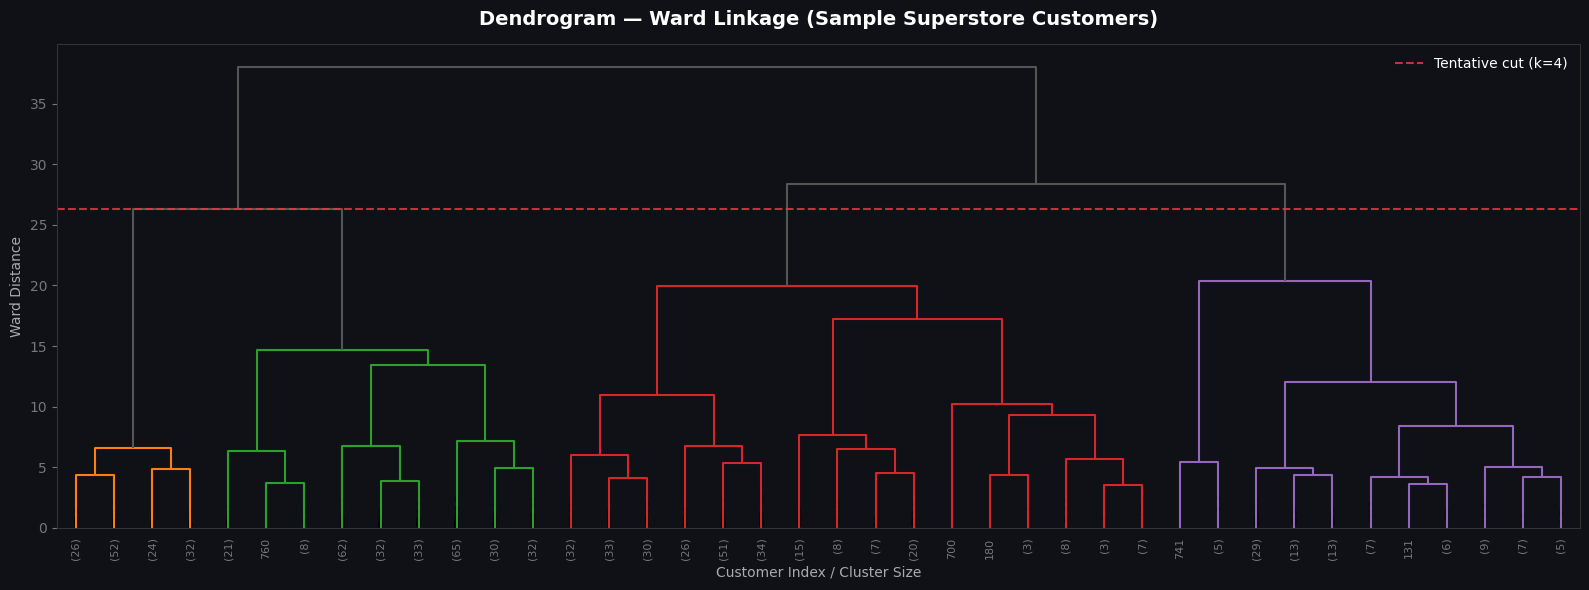

In [15]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.set_title("Dendrogram — Ward Linkage (Sample Superstore Customers)",
             fontsize=14, fontweight="bold", color="white", pad=14)

dendrogram(
    Z, ax=ax,
    truncate_mode="lastp", p=40,
    leaf_rotation=90, leaf_font_size=8,
    color_threshold=Z[-3, 2],          # tentative cut at k=4
    above_threshold_color="#555555",
    show_contracted=True,
)
ax.axhline(y=Z[-3, 2], color="#E63946", linestyle="--", linewidth=1.5,
           alpha=0.85, label="Tentative cut (k=4)")
ax.legend(framealpha=0, fontsize=10)
ax.set_xlabel("Customer Index / Cluster Size", color="#AAAAAA")
ax.set_ylabel("Ward Distance", color="#AAAAAA")
plt.tight_layout()
plt.show()


## 8 · Optimal *k* via Silhouette Score

Evaluate cluster quality using Silhouette Score

The model tests different cluster counts (k=2 to k=8) to identify the most meaningful customer segmentation structure.

Results show that k=2 achieved the highest silhouette score, indicating the clearest separation between customer groups.

However, the relatively low **score (~0.23)** suggests that customer behavior overlaps across clusters, meaning the segmentation structure is moderate rather than strongly distinct.

This is common in real-world retail datasets where customer purchasing patterns are complex and not perfectly separable.

In [16]:
sil_scores = {}
for k in range(2, 9):
    model  = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE_METHOD)
    labels = model.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)
    print(f"  k={k}  Silhouette={sil_scores[k]:.4f}")

optimal_k = max(sil_scores, key=sil_scores.get)
print(f"\n✅ Optimal k = {optimal_k}  (Silhouette = {sil_scores[optimal_k]:.4f})")

  k=2  Silhouette=0.2325
  k=3  Silhouette=0.2032
  k=4  Silhouette=0.2036
  k=5  Silhouette=0.2108
  k=6  Silhouette=0.2124
  k=7  Silhouette=0.2184
  k=8  Silhouette=0.2150

✅ Optimal k = 2  (Silhouette = 0.2325)


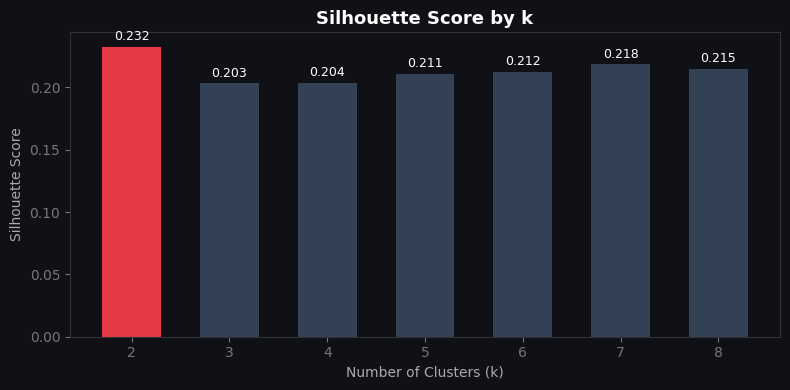

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ks, scores = list(sil_scores.keys()), list(sil_scores.values())
bar_colors = [PALETTE[0] if k == optimal_k else "#334155" for k in ks]
bars = ax.bar(ks, scores, color=bar_colors, edgecolor="none", width=0.6)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{score:.3f}", ha="center", va="bottom", fontsize=9, color="white")
ax.set_title("Silhouette Score by k", fontsize=13, fontweight="bold", color="white")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(ks)
plt.tight_layout()
plt.show()

## 9 · Fit Final Model & Assign Clusters

In [18]:
final_model = AgglomerativeClustering(n_clusters=optimal_k, linkage=LINKAGE_METHOD)
customer_df["Cluster"] = final_model.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, customer_df["Cluster"])
print(f"Final Silhouette Score (k={optimal_k}): {final_sil:.4f}")
customer_df["Cluster"].value_counts().sort_index()

Final Silhouette Score (k=2): 0.2325


,count
Cluster,
0,375
1,418


## 10 · Visualise Clusters


## Cluster Analysis - Fraud Signal Interpretation


Hierarchical clustering on four customer-level features (Total Sales,
Total Profit, Avg Discount, Total Quantity) revealed two distinct behavioural
segments. While the separation appears across both scatter plots, the pattern
that emerges tells a deeper story — one that is central to this fraud
detection objective.

## ── CLUSTER 0 — Baseline / Normal Behaviour

Customers in this cluster exhibit behaviour consistent with legitimate
purchasing activity:

   • Higher total sales and profit contribution
   • Greater quantity ordered across transactions
   • Lower average discount received

This follows the expected retail logic: volume justifies margin concessions,
and the business is compensated for any discount given.

## ── CLUSTER 1 — Anomalous / High-Risk Behaviour

Cluster 1 breaks the fundamental retail reward structure entirely:

   • Low total sales and near-zero or negative profit generation
   • Low total quantity ordered — no volume to justify preferential treatment
   • Disproportionately high average discounts (ranging 0.30 – 0.70)

These accounts are extracting the highest discounts from the system while
contributing the least value in return. This inverse relationship between
discount received and business value generated is a textbook unsupervised
fraud signal.

## ── Fraud Hypothesis

The cluster boundary is not a natural market segmentation — it is a
behavioural anomaly. Three fraud vectors are consistent with this pattern:

   1. DISCOUNT ABUSE — Unauthorised or manipulated discount application,
      potentially through collusion with internal sales representatives
      or exploitation of discount/loyalty code systems.

   2. MARGIN EROSION FRAUD — High discount + low quantity + low profit
      violates the volume-offset principle of legitimate bulk discounting.
      The business absorbs the margin loss with no compensating revenue.

   3. RETURN ARBITRAGE — Buy at heavily discounted price, return at or near
      full price — a common retail fraud pattern that surfaces as high
      discount with low net sales value.

## ── Key Insight

In a healthy retail system, discount allocation and purchasing contribution
move in the same direction. Cluster 1 inverts this relationship entirely.
The reward is inversely proportional to the contribution — a pattern that
cannot be explained by legitimate customer behaviour alone.

Cluster 1 accounts are flagged as HIGH-RISK and will be carried forward
into the next investigative layer for deeper feature engineering, including:

   → Discount-to-Profit ratio analysis
   → Order frequency vs return rate
   → Geographic and temporal concentration of anomalous discounts
   → Sales representative cross-referencing for insider threat assessment

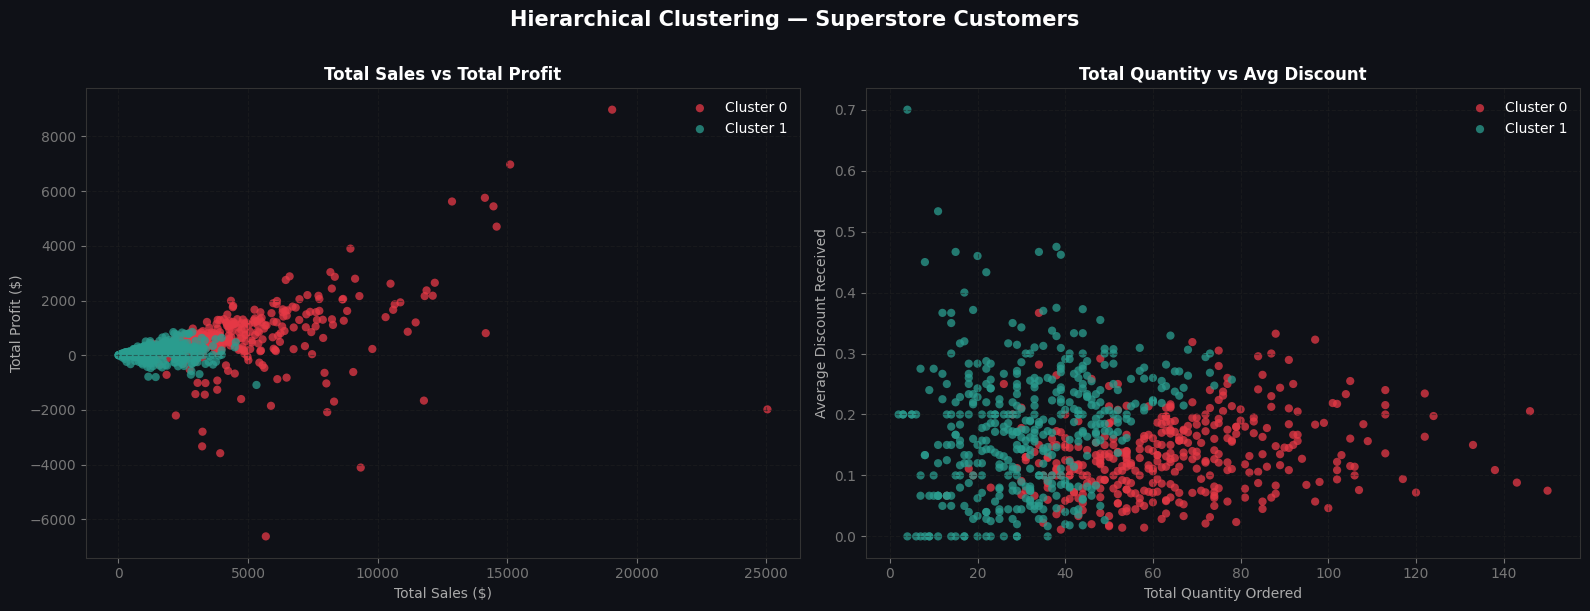

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Hierarchical Clustering — Superstore Customers",
             fontsize=15, fontweight="bold", color="white", y=1.01)

# --- Sales vs Profit ---
ax = axes[0]
for k in range(optimal_k):
    mask = customer_df["Cluster"] == k
    ax.scatter(customer_df.loc[mask, "Total_Sales"],
               customer_df.loc[mask, "Total_Profit"],
               c=PALETTE[k], label=f"Cluster {k}", s=35, alpha=0.75, edgecolors="none")
ax.set_title("Total Sales vs Total Profit", fontweight="bold")
ax.set_xlabel("Total Sales ($)")
ax.set_ylabel("Total Profit ($)")
ax.legend(framealpha=0, labelcolor="white")
ax.grid(True)

# --- Quantity vs Avg Discount ---
ax = axes[1]
for k in range(optimal_k):
    mask = customer_df["Cluster"] == k
    ax.scatter(customer_df.loc[mask, "Total_Quantity"],
               customer_df.loc[mask, "Avg_Discount"],
               c=PALETTE[k], label=f"Cluster {k}", s=35, alpha=0.75, edgecolors="none")
ax.set_title("Total Quantity vs Avg Discount", fontweight="bold")
ax.set_xlabel("Total Quantity Ordered")
ax.set_ylabel("Average Discount Received")
ax.legend(framealpha=0, labelcolor="white")
ax.grid(True)

plt.tight_layout()
plt.show()

## 11 · Cluster Profiling & Business Interpretation

### Cluster profile summary

This block builds a statistical identity card for each cluster — computing the
average behaviour across all four features, the customer count per cluster, and
each cluster's share of the total customer base.

The output confirms numerically what the scatter plots revealed visually:
Cluster 1 carries a disproportionately high average discount relative to its
sales and profit contribution, while Cluster 0 reflects the expected pattern
of a healthy, margin-positive customer segment.

In [20]:
profile = customer_df.groupby("Cluster")[features].mean().round(2)
profile["Count"] = customer_df["Cluster"].value_counts().sort_index()
profile["% of Customers"] = (profile["Count"] / len(customer_df) * 100).round(1)
print(profile.to_string())

         Total_Sales  Total_Profit  Total_Quantity  Avg_Discount  Count  % of Customers
Cluster                                                                                
0            4524.59        648.82           64.62          0.13    375            47.3
1            1436.56        103.08           32.63          0.18    418            52.7


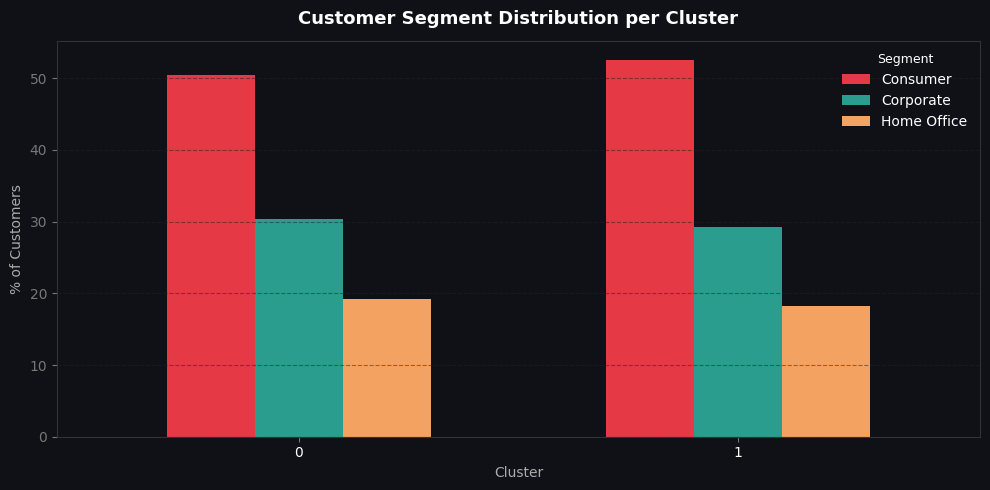

In [21]:
# Segment distribution within each cluster
seg_dist = customer_df.groupby(["Cluster", "Segment"]).size().unstack(fill_value=0)
seg_dist_pct = seg_dist.div(seg_dist.sum(axis=1), axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(10, 5))
seg_dist_pct.plot(
    kind="bar", ax=ax,
    color=["#E63946", "#2A9D8F", "#F4A261"],
    edgecolor="none", width=0.6
)
ax.set_title("Customer Segment Distribution per Cluster",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("% of Customers")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, color="white")
ax.legend(title="Segment", framealpha=0, labelcolor="white", title_fontsize=9)
ax.grid(axis="y")
plt.tight_layout()
plt.show()

## Customer Segment Distribution Per Cluster

The segment breakdown across Cluster 0 and Cluster 1 is near-identical —
Consumer, Corporate, and Home Office maintain almost the same proportional
representation in both clusters.

This rules out customer segment as the driver of the anomalous behaviour
observed in Cluster 1. The fraud signal is not concentrated in any one
segment — it cuts across all three equally.

This is a significant finding: it suggests the discount abuse pattern
identified in Cluster 1 is not a segment-level phenomenon but rather an
account-level or transaction-level manipulation that transcends customer
category boundaries. No segment is immune, and no segment can be isolated
as the sole risk vector.

The investigation must therefore look beyond who the customer is — and focus
on how and by whom the discounts are being applied.

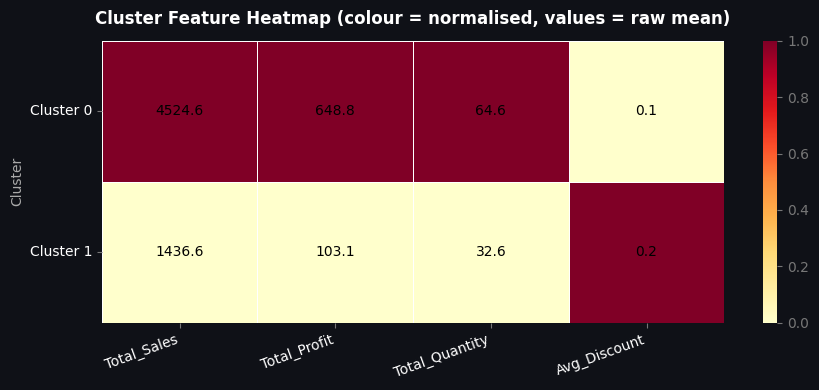

In [22]:
# Heatmap of normalised cluster profiles
from sklearn.preprocessing import MinMaxScaler

profile_vals = profile[features]
norm_profile = pd.DataFrame(
    MinMaxScaler().fit_transform(profile_vals),
    index=profile_vals.index,
    columns=features
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(norm_profile, annot=profile_vals.values, fmt=".1f",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            annot_kws={"size": 10, "color": "black"})
ax.set_title("Cluster Feature Heatmap (colour = normalised, values = raw mean)",
             fontsize=12, fontweight="bold", color="white", pad=12)
ax.set_xlabel("")
ax.set_yticklabels([f"Cluster {i}" for i in norm_profile.index], rotation=0, color="white")
ax.set_xticklabels(features, rotation=20, ha="right", color="white")
plt.tight_layout()
plt.show()